In [1]:
import logic.pulsed.pulse_objects as po
from logic.pulsed.sampling_functions import SamplingFunctions as SF
import time
import matplotlib.pyplot as plt
import pickle
import datetime
from tqdm import tqdm
from matplotlib.pyplot import cm
import numpy as np
pjl = pulsedjupyterlogic_AWG #Make sure the Logic is started in the Qudi manager!!!!

In [2]:
def setup_autoapproach():
    #configuration of autoapproach settings
    # for HFAmpl signal

    threshold = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_SETP_DISP')) / 1e7
    spm._dev.aap.setAApThreshold(threshold)

    # dF     8
    # HFAmpl       13
    input_signal = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_INPUT'))
    threshold_cond = 1 if input_signal==13 else 0        
    spm._dev.aap.setAApStopCondition(threshold_cond) # [0, 1] >threshold/<threshold
    spm._dev.aap.setAApStepsPerApproach(0)

    spm._dev.aap.setAApAproachMode(1) # [0, 1] Ramp/Loop
    spm._dev.aap.setAApModeAfter(0) # [0, 1, 2] On/Retract/Off

def get_pos(reps=5):
    pos = 0
    for i in range(reps):
        pos = pos+ spm.get_sample_pos()['Z']
        time.sleep(0.005)
    return pos/reps

def go_into_contact():
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_AAP_CTRL'), 1, 0)
    while not spm.is_probe_landed():
        time.sleep(0.001)
    time.sleep(0.5)
        
def do_lift_off(lift_off_height):
    pos = get_pos()
    new_pos = pos - lift_off_height
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_LOOP_ON'), 0, 0)
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_SET_Z_M'), new_pos*1e12, 0)

#### Define general measurement params

In [10]:
#measurement parameters
laser_power_voltage = 0.1#podmrlogic.laser_power_voltage

#additional information for save tag
tip_name = 'A-H12-13'
sample = 'YBCO'
temperature = '80K'
b_field = '5mT_OOP_FC'
contact = 'OOC'
res_freq = 32.16e3
extra = f'{res_freq/1e3}kHz'

#### Run t_0 PL oscillation sweep
Make sure the analysis method is set to sum and the analysis window is set correctly

100%|#####################################################################################| 40/40 [05:33<00:00,  8.35s/it]


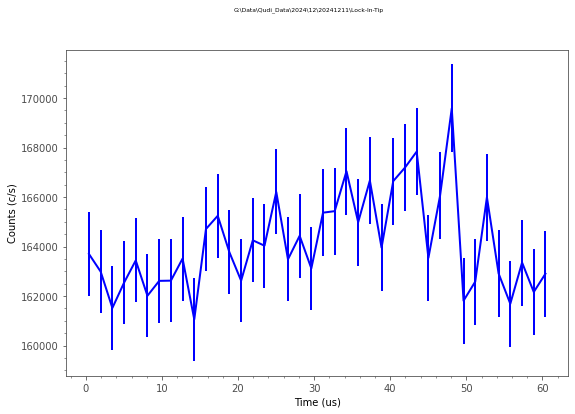

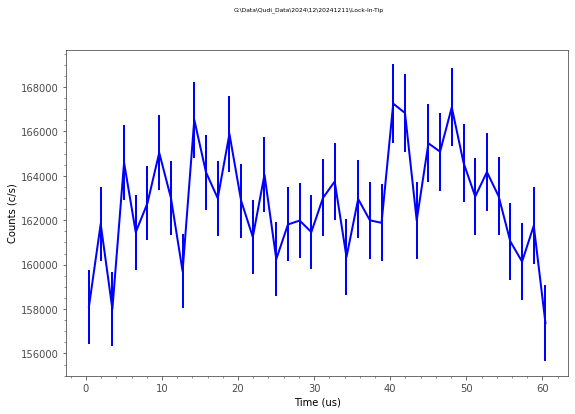

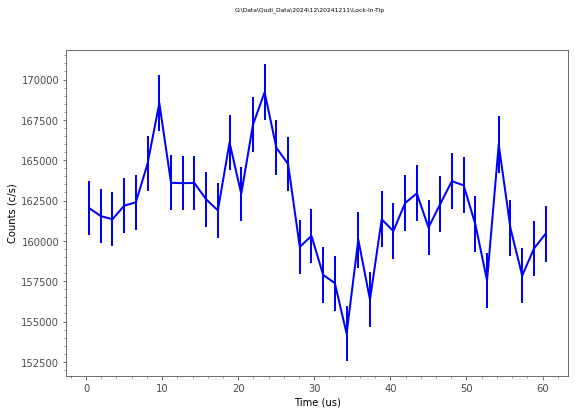

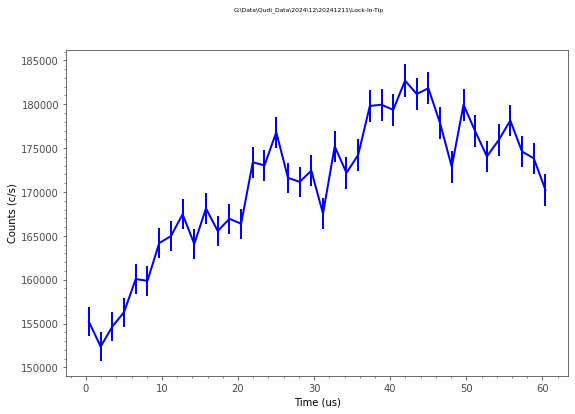

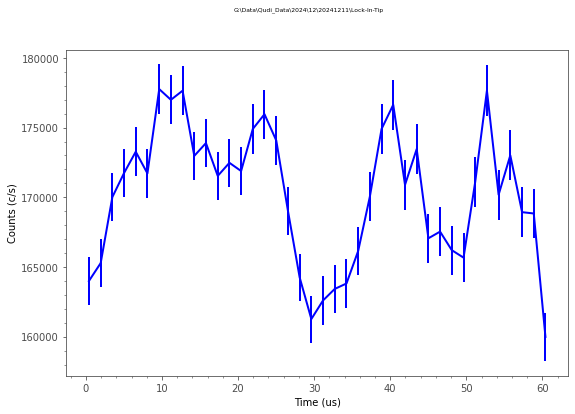

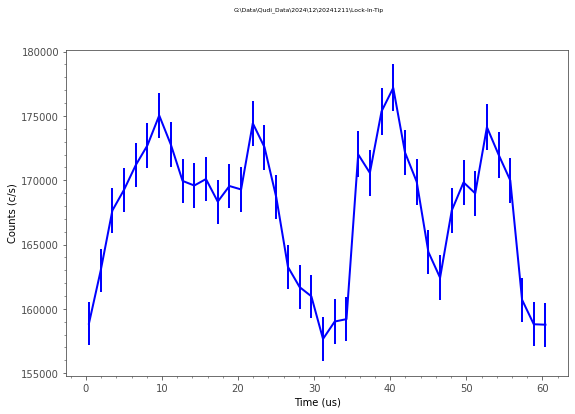

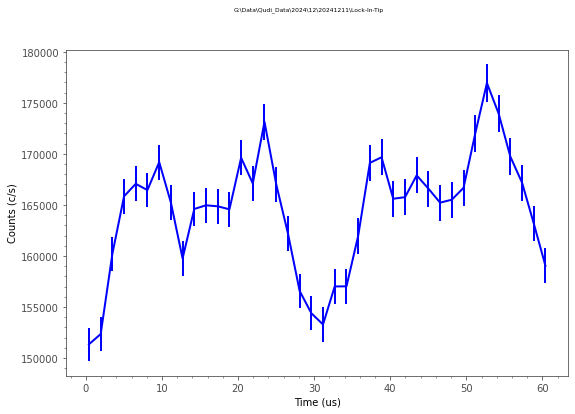

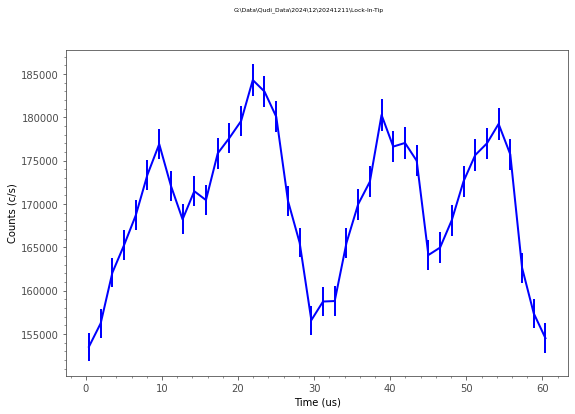

In [11]:
TF_Amp_arr = np.arange(0.1, 1.7, 0.2)
# TF_Amp_arr = [1.01]
HF_Ampl = [0.313, 0.952, 1.597, 2.248, 2.784, 3.298, 3.810, 4.298] #None
wait_bw_TF_set = 5

t0_start = 0
t0_stop = 60e-6
t0_num = 40
max_sweeps = 150000

alternating = False
t0_sweep_init = np.linspace(t0_start, t0_stop, t0_num)
t0_sweep = np.zeros_like(t0_sweep_init)
PL_osc = np.zeros_like(t0_sweep_init)
PL_osc_sweeps = np.zeros_like(t0_sweep_init)
PL_osc_err = np.zeros_like(t0_sweep_init)
afm_scanner_logic.jupyter_meas_stop = False

analysis_time = pulsedmasterlogic_AWG.analysis_settings['signal_end']-pulsedmasterlogic_AWG.analysis_settings['signal_start']

meas_dict = {}

for idx, TF_Amp in enumerate(TF_Amp_arr):
    spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
    time.sleep(wait_bw_TF_set)

    for i, t_0 in enumerate(tqdm(t0_sweep_init)):
        pjl.initialize_ensemble(laser_power_voltage = laser_power_voltage,
                                trigger_type = 'pos_edge_rearm', trigger_level0 = 400, trigger_level1 = -200)

        ret = pjl.PL_Osc_gradiometry(t_0)
        t0_sweep[i] = ret[5]
#         print(ret[5]/1e-6, " - Actual T_0 time used in (us)")
        pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps = 0
        pjl.start_measurement(measurement_type='PL_Osc_gradiometry', tip_name=tip_name, sample=sample, 
                              temperature=temperature, b_field=b_field, contact=contact, extra=extra)

        while True and not afm_scanner_logic.jupyter_meas_stop:
            if pulsedmasterlogic_AWG.elapsed_sweeps>max_sweeps:
                pulsedmeasurementlogic_AWG.stop_pulsed_measurement()
                PL_osc[i]  = pulsedmasterlogic_AWG.signal_data[1][0]/analysis_time/pulsedmasterlogic_AWG.elapsed_sweeps
                PL_osc_err[i]  = pulsedmasterlogic_AWG.measurement_error[1][0]/analysis_time/pulsedmasterlogic_AWG.elapsed_sweeps
                PL_osc_sweeps[i]  = pulsedmasterlogic_AWG.elapsed_sweeps
                break
            else:
                time.sleep(0.01)

        if afm_scanner_logic.jupyter_meas_stop:
            break


    meas_dict[TF_Amp] = {"t0_sweep": t0_sweep.copy(), "PL_Osc": PL_osc.copy(), "PL_osc_err": PL_osc_err.copy(), "PL_osc_sweeps": PL_osc_sweeps.copy(), 'Hf_ampl': HF_Ampl[idx]}
    
    fig, ax1 = plt.subplots(1,1)
    ax1.errorbar(x=t0_sweep/1e-6, y=PL_osc,
                             yerr=PL_osc_err, fmt='b-', label=f'')

    ax1.set_xlabel('Time (us)')
    ax1.set_ylabel('Counts (c/s)')

    filelabel = tip_name+'_'+extra
    parameters = {'Res_freq':res_freq, 'A_exc':TF_Amp, 'Hf_ampl': HF_Ampl[idx], "Note": ""}
    data =  {'Time (us), Counts (c/s), Counts_err, Elapsed_sweeps': np.array((t0_sweep, PL_osc, PL_osc_err, PL_osc_sweeps)).T}
    filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip')
    fig.suptitle(filepath, fontsize=6)
    plt.show()
    savelogic.save_data(data, parameters=parameters, filepath=filepath, filelabel=filelabel, plotfig=fig, delimiter='\t')

string = datetime.datetime.now().isoformat('_','seconds')+'_'+'PL_Osc_Exc_sweep'+'_'+tip_name+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)

#### Load and ready Gradiometry sequence with lift off

100%|#####################################################################################| 40/40 [09:25<00:00, 14.13s/it]


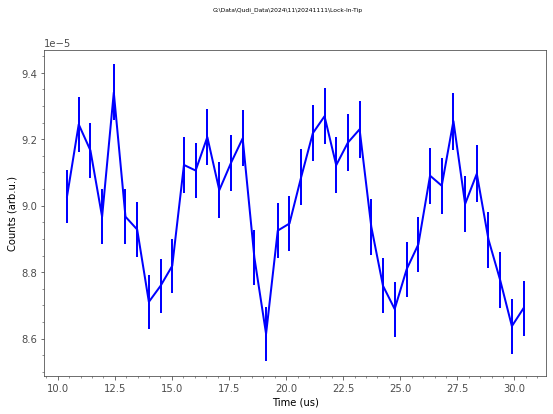

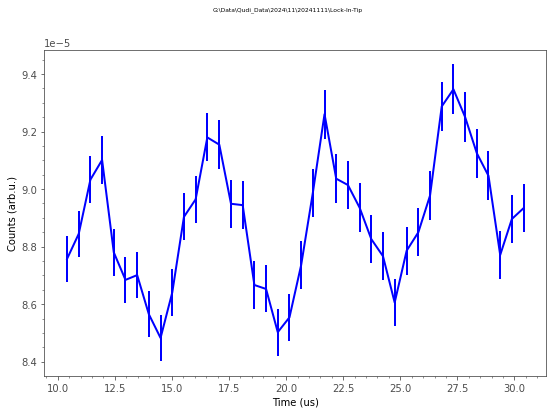

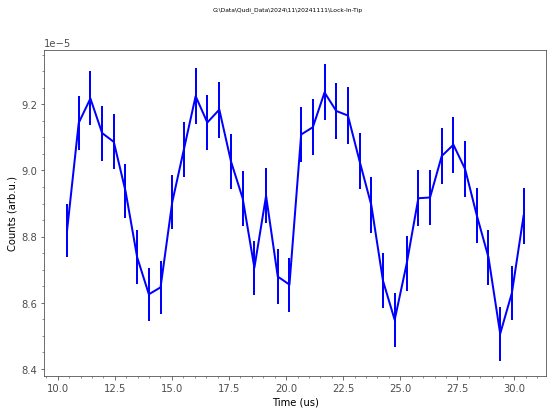

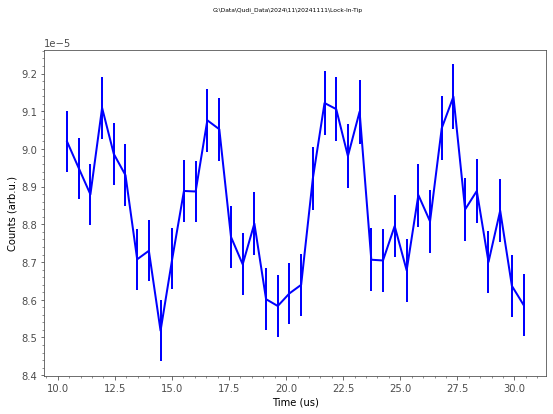

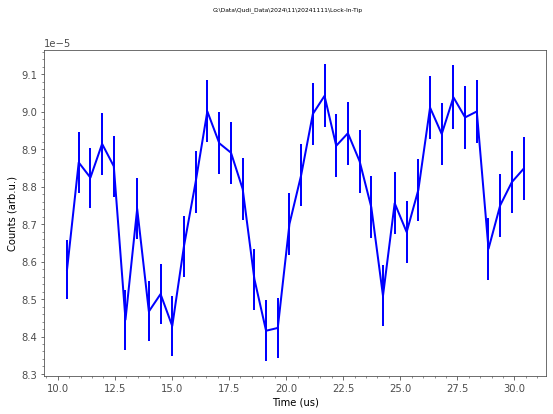

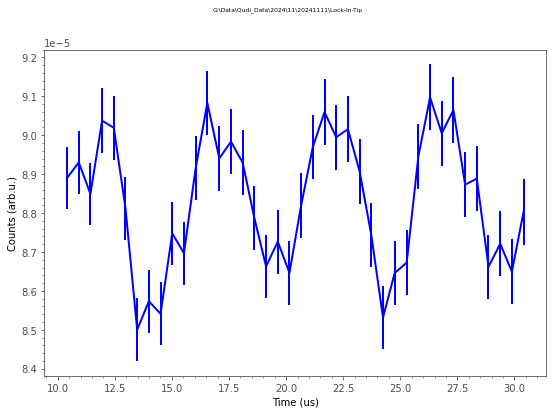

In [4]:
# TF_Amp_arr = np.linspace(2, 2, 1)
TF_Amp_arr = [4.0]
HF_Ampl = 0.205 #None

lift_off_height_list = np.linspace(10e-9, 50e-9, 6)
lift_off_check_period = 60*5

wait_bw_TF_set = 0

t0_start = 10e-6
t0_stop = 30e-6
t0_num = 40
max_sweeps = 4e5

alternating = False
t0_sweep_init = np.linspace(t0_start, t0_stop, t0_num)
t0_sweep = np.zeros_like(t0_sweep_init)
PL_osc = np.zeros_like(t0_sweep_init)
PL_osc_sweeps = np.zeros_like(t0_sweep_init)
PL_osc_err = np.zeros_like(t0_sweep_init)
afm_scanner_logic.jupyter_meas_stop = False

meas_dict = {}

setup_autoapproach()
go_into_contact()

for lift_off_height in lift_off_height_list:
#     spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
#     time.sleep(wait_bw_TF_set)

    for i, t_0 in enumerate(tqdm(t0_sweep_init)):
        pjl.initialize_ensemble(laser_power_voltage = laser_power_voltage, pi_pulse=pi_pulse, 
                                pi_pulse_1=pi_pulse_1, LO_freq_0=LO_freq_0, target_freq_0=target_freq_0, 
                                power_0=power_0, LO_freq_1=LO_freq_1, target_freq_1=target_freq_1, power_1=power_1, 
                                switch_MW = switch_MW, trigger_type = 'pos_edge_rearm', trigger_level0 = 400, trigger_level1 = -200)

        ret = pjl.PL_Osc_gradiometry(t_0)
        t0_sweep[i] = ret[5]
#         print(ret[5]/1e-6, " - Actual T_0 time used in (us)")
        pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps = 0
    
        #Lift off
        lift_off_start = 0
        if lift_off_height > 0:
            do_lift_off(lift_off_height)
            lift_off_start = time.time()
            
        pjl.start_measurement(measurement_type='PL_Osc_gradiometry', tip_name=tip_name, sample=sample, 
                              temperature=temperature, b_field=b_field, contact=contact, extra=extra)

        while True and not afm_scanner_logic.jupyter_meas_stop:
            if abs(lift_off_start-time.time())>=lift_off_check_period and lift_off_height > 0 and lift_off_check_period > 0:
                pulsedmeasurementlogic_AWG.pause_pulsed_measurement()
                go_into_contact()
                do_lift_off(lift_off_height)
                lift_off_start = time.time()
                pulsedmeasurementlogic_AWG.continue_pulsed_measurement()
            
            if pulsedmasterlogic_AWG.elapsed_sweeps>max_sweeps:
                pulsedmeasurementlogic_AWG.stop_pulsed_measurement()
                PL_osc[i]  = pulsedmasterlogic_AWG.signal_data[1][0]
                PL_osc_err[i]  = pulsedmasterlogic_AWG.measurement_error[1][0]
                PL_osc_sweeps[i]  = pulsedmasterlogic_AWG.elapsed_sweeps
                break
            else:
                time.sleep(0.01)

        go_into_contact()      
        
        if afm_scanner_logic.jupyter_meas_stop:
            break


    meas_dict[lift_off_height] = {"t0_sweep": t0_sweep.copy(), "PL_Osc": PL_osc.copy(), "PL_osc_err": PL_osc_err.copy(), "PL_osc_sweeps": PL_osc_sweeps.copy()}
    
    fig, ax1 = plt.subplots(1,1)
    ax1.errorbar(x=t0_sweep/1e-6, y=PL_osc/PL_osc_sweeps,
                             yerr=PL_osc_err/PL_osc_sweeps, fmt='b-', label=f'')

    ax1.set_xlabel('Time (us)')
    ax1.set_ylabel('Counts (arb.u.)')

    filelabel = tip_name
    parameters = {'Res_freq':190e3, 'A_exc':TF_Amp, 'Hf_ampl': HF_Ampl, "Note": ""}
    data =  {'Time (us), Counts (arb.u.), Counts_err, Elapsed_sweeps': np.array((t0_sweep, PL_osc, PL_osc_err, PL_osc_sweeps)).T}
    filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip')
    fig.suptitle(filepath, fontsize=6)
    plt.show()
    savelogic.save_data(data, parameters=parameters, filepath=filepath, filelabel=filelabel, plotfig=fig, delimiter='\t')

spm.retract_probe()
string = datetime.datetime.now().isoformat('_','seconds')+'_'+'PL_Osc_Exc_sweep'+'_'+tip_name
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)

Pickle load

In [39]:
root = r"G:\Data\Qudi_Data\2024\10\20241031\Lock-In-Tip"
path = root +"\\"+ "2024-10-31_12-09-16_PL_Osc_Exc_sweep_L-R-04-18" 
with open(path+'.pickle', 'rb') as f:
    data = pickle.load(f)

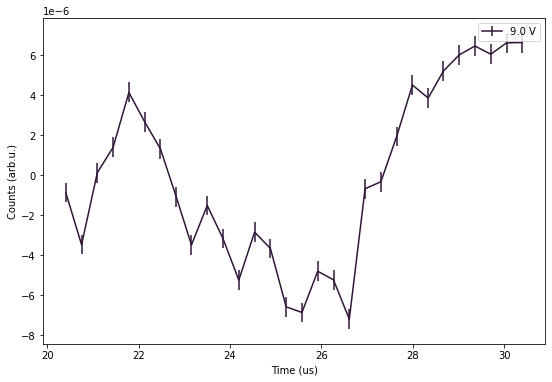

100%|#####################################################################################| 30/30 [03:30<00:00,  7.01s/it]


In [45]:
fig, ax1 = plt.subplots(1,1)

cl = cm.twilight_shifted(list(data.keys()))
for i, key in enumerate(data.keys()):
    t0_sweep = data[key]["t0_sweep"]
    PL_osc = data[key]["PL_Osc"]
    PL_osc_sweeps = data[key]["PL_osc_sweeps"]
    PL_osc_err = data[key]["PL_osc_err"]
    c = PL_osc/PL_osc_sweeps
    c = c - np.mean(c)
#     c /= c.max()
    ax1.errorbar(x=t0_sweep/1e-6, y=c,
                             yerr=PL_osc_err/PL_osc_sweeps,color=cl[i], 
                             label=f'{key} V')

    ax1.set_xlabel('Time (us)')
    ax1.set_ylabel('Counts (arb.u.)')
plt.legend()
plt.show()